# Taxi Trip Duration Prediction


In [1]:
import matplotlib.pyplot as plt
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.feature import (
    OneHotEncoder,
    StandardScaler,
    StringIndexer,
    VectorAssembler,
)
from pyspark.ml.regression import GBTRegressor, LinearRegression, RandomForestRegressor
from pyspark.ml.tuning import ParamGridBuilder, TrainValidationSplit
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, unix_timestamp

In [2]:
spark = (
    SparkSession.builder.config("spark.executor.memory", "10g")
    .config("spark.driver.memory", "10g")
    .appName("trip_duration_prediction")
    .getOrCreate()
)
spark

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
25/10/20 21:29:09 WARN Utils: Your hostname, legion-5i, resolves to a loopback address: 127.0.1.1; using 192.168.1.11 instead (on interface wlp0s20f3)
25/10/20 21:29:09 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/10/20 21:29:10 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [3]:
df = spark.read.parquet("datasets/yellow_tripdata_2015-01.parquet")
df.show()

+--------+--------------------+---------------------+---------------+-------------+------------------+------------------+----------+------------------+------------------+------------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|  pickup_longitude|   pickup_latitude|RateCodeID|store_and_fwd_flag| dropoff_longitude|  dropoff_latitude|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|
+--------+--------------------+---------------------+---------------+-------------+------------------+------------------+----------+------------------+------------------+------------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+
|       1| 2015-01-13 11:46:19|  2015-01-13 12:08:42|              2|          2.6|   -74.00537109375|40.737003326416016|         1|    

In [4]:
df.printSchema()

root
 |-- VendorID: integer (nullable = true)
 |-- tpep_pickup_datetime: timestamp (nullable = true)
 |-- tpep_dropoff_datetime: timestamp (nullable = true)
 |-- passenger_count: integer (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- pickup_longitude: double (nullable = true)
 |-- pickup_latitude: double (nullable = true)
 |-- RateCodeID: integer (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- dropoff_longitude: double (nullable = true)
 |-- dropoff_latitude: double (nullable = true)
 |-- payment_type: integer (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)



In [5]:
df = df.na.drop()
df.count()

12748983

## Data Cleaning


Clean invalid data


In [6]:
# New York is bounded by the coordinates (latitude, longitude) = (40.5774, -74.15) and (40.9176, -73.7004)

df = df.where(
    df.pickup_longitude.between(-74.15, -73.7004)
    & df.pickup_latitude.between(40.5774, 40.9176)
    & df.dropoff_longitude.between(-74.15, -73.7004)
    & df.dropoff_latitude.between(40.5774, 40.9176)
)
df.count()

12455067

In [7]:
df = df.withColumn(
    "trip_duration",
    (unix_timestamp("tpep_dropoff_datetime") - unix_timestamp("tpep_pickup_datetime"))
    / 60,
)
df.show()

+--------+--------------------+---------------------+---------------+-------------+------------------+------------------+----------+------------------+------------------+------------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+------------------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|  pickup_longitude|   pickup_latitude|RateCodeID|store_and_fwd_flag| dropoff_longitude|  dropoff_latitude|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|     trip_duration|
+--------+--------------------+---------------------+---------------+-------------+------------------+------------------+----------+------------------+------------------+------------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+------------------+
|       1| 2015-01-13 11:46:19|  2015-01-13 12:08:42|              2|          

In [8]:
# As per NYC TLC Regulations, the maximum allowed trip time in a 24 hour interval is 12 hours.

df = df.where(df.trip_duration.between(0, 12 * 60))
df.select("trip_duration").orderBy("trip_duration", ascending=False).show()
df.count()

+-----------------+
|    trip_duration|
+-----------------+
|719.7666666666667|
|719.6333333333333|
|719.6166666666667|
|719.6166666666667|
|719.4833333333333|
|719.0666666666667|
|718.2833333333333|
|717.4333333333333|
|716.9666666666667|
|715.6833333333333|
|            714.5|
|           714.05|
|713.9333333333333|
|713.2166666666667|
|713.1833333333333|
|712.5333333333333|
|712.4833333333333|
|712.1666666666666|
|712.0333333333333|
|711.6833333333333|
+-----------------+
only showing top 20 rows


12446490

In [9]:
df = df.drop("tpep_pickup_datetime", "tpep_dropoff_datetime")
df

DataFrame[VendorID: int, passenger_count: int, trip_distance: double, pickup_longitude: double, pickup_latitude: double, RateCodeID: int, store_and_fwd_flag: string, dropoff_longitude: double, dropoff_latitude: double, payment_type: int, fare_amount: double, extra: double, mta_tax: double, tip_amount: double, tolls_amount: double, improvement_surcharge: double, total_amount: double, trip_duration: double]

In [10]:
# NYC Taxi can hold up to 6 passengers

df = df.where(df.passenger_count.between(0, 6))
df.count()

12446469

In [11]:
# Feature only includes $0.50 and $1 rush hour and overnight charges.

df = df.where(df.extra.between(0, 1.5))
df.count()

12444668

In [12]:
# 0.5 MTA tax is automatically triggered.

df = df.where(col("mta_tax") == 0.5)
df.count()

12421485

In [13]:
# 0.30 improvement surcharge, began being levied in 2015

df = df.where(
    (col("improvement_surcharge") == 0.3) | (col("improvement_surcharge") == 0.0)
)
df.count()

12421485

Clean data based on analysis


In [14]:
df = df.where(df.trip_distance.between(0, 302.1))
df = df.where(df.fare_amount.between(0, 441.6))
df = df.where(df.tip_amount.between(0, 888.2))
df = df.where(df.tolls_amount.between(0, 33.0436))
df = df.where(df.total_amount.between(-400.3, 4009.3))
df.count()

25/10/20 21:29:53 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


12421295

In [15]:
df.describe(
    [
        "passenger_count",
        "trip_distance",
        "pickup_longitude",
        "pickup_latitude",
        "dropoff_longitude",
        "dropoff_latitude",
        "fare_amount",
        "extra",
        "mta_tax",
        "tip_amount",
        "tolls_amount",
        "improvement_surcharge",
        "total_amount",
        "trip_duration",
    ]
).show()

+-------+------------------+-----------------+--------------------+--------------------+--------------------+--------------------+------------------+------------------+--------+------------------+------------------+---------------------+------------------+------------------+
|summary|   passenger_count|    trip_distance|    pickup_longitude|     pickup_latitude|   dropoff_longitude|    dropoff_latitude|       fare_amount|             extra| mta_tax|        tip_amount|      tolls_amount|improvement_surcharge|      total_amount|     trip_duration|
+-------+------------------+-----------------+--------------------+--------------------+--------------------+--------------------+------------------+------------------+--------+------------------+------------------+---------------------+------------------+------------------+
|  count|          12421295|         12421295|            12421295|            12421295|            12421295|            12421295|          12421295|          12421295|1242

## Data Preprocessing


In [16]:
train, test = df.randomSplit([0.9, 0.1], seed=42)
train.cache()
test.cache()

DataFrame[VendorID: int, passenger_count: int, trip_distance: double, pickup_longitude: double, pickup_latitude: double, RateCodeID: int, store_and_fwd_flag: string, dropoff_longitude: double, dropoff_latitude: double, payment_type: int, fare_amount: double, extra: double, mta_tax: double, tip_amount: double, tolls_amount: double, improvement_surcharge: double, total_amount: double, trip_duration: double]

In [17]:
indexer = StringIndexer(
    inputCols=["store_and_fwd_flag", "RateCodeID"],
    outputCols=["store_and_fwd_flag_indexed", "RateCodeID_indexed"],
)

encoder = OneHotEncoder(
    inputCols=[
        "VendorID",
        "RateCodeID_indexed",
        "store_and_fwd_flag_indexed",
        "payment_type",
    ],
    outputCols=[
        "VendorID_vec",
        "RateCodeID_vec",
        "store_and_fwd_flag_vec",
        "payment_type_vec",
    ],
    handleInvalid="keep",
)

In [18]:
assembler = VectorAssembler(
    inputCols=[
        "passenger_count",
        "trip_distance",
        "pickup_longitude",
        "pickup_latitude",
        "dropoff_longitude",
        "dropoff_latitude",
        "fare_amount",
        "extra",
        "mta_tax",
        "tip_amount",
        "tolls_amount",
        "improvement_surcharge",
        "total_amount",
    ]
    + [
        "VendorID_vec",
        "RateCodeID_vec",
        "store_and_fwd_flag_vec",
        "payment_type_vec",
    ],
    outputCol="feature_vector",
)

scaler = StandardScaler(inputCol="feature_vector", outputCol="scaled_feature_vector")

# Prediction


Linear Regression


In [19]:
linear_regression = LinearRegression(
    featuresCol="feature_vector", labelCol="trip_duration"
)

pipeline = Pipeline(stages=[indexer, encoder, assembler, scaler, linear_regression])

evaluator = RegressionEvaluator(predictionCol="prediction", labelCol="trip_duration")

In [20]:
param_grid = (
    ParamGridBuilder().addGrid(linear_regression.regParam, [0.01, 0.1, 1.0]).build()
)

train_validation = TrainValidationSplit(
    estimator=pipeline,
    estimatorParamMaps=param_grid,
    evaluator=evaluator,
    trainRatio=0.9,
    seed=42,
)

In [21]:
model = train_validation.fit(train)
predictions = model.transform(test)
predictions.show()

+--------+---------------+-------------+------------------+------------------+----------+------------------+------------------+------------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+------------------+--------------------------+------------------+-------------+--------------+----------------------+----------------+--------------------+---------------------+------------------+
|VendorID|passenger_count|trip_distance|  pickup_longitude|   pickup_latitude|RateCodeID|store_and_fwd_flag| dropoff_longitude|  dropoff_latitude|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|     trip_duration|store_and_fwd_flag_indexed|RateCodeID_indexed| VendorID_vec|RateCodeID_vec|store_and_fwd_flag_vec|payment_type_vec|      feature_vector|scaled_feature_vector|        prediction|
+--------+---------------+-------------+------------------+------------------+----------+------------------+----------

In [22]:
best_model = model.bestModel.stages[-1]
print("regParam", best_model.getRegParam())

regParam 0.01


In [23]:
linear_regression_rmse = evaluator.evaluate(predictions)
linear_regression_rmse

6.4535698495297575

Random Forest


In [24]:
random_forest = RandomForestRegressor(
    featuresCol="feature_vector", labelCol="trip_duration", seed=42
)

pipeline = Pipeline(stages=[indexer, encoder, assembler, scaler, random_forest])

In [25]:
param_grid = (
    ParamGridBuilder()
    .addGrid(random_forest.minInstancesPerNode, [1, 5])
    .addGrid(random_forest.minInfoGain, [0, 0.1])
    .build()
)

train_validation = TrainValidationSplit(
    estimator=pipeline,
    estimatorParamMaps=param_grid,
    evaluator=evaluator,
    trainRatio=0.9,
    seed=42,
)

In [26]:
model = train_validation.fit(train)
predictions = model.transform(test)
predictions.show()

+--------+---------------+-------------+------------------+------------------+----------+------------------+------------------+------------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+------------------+--------------------------+------------------+-------------+--------------+----------------------+----------------+--------------------+---------------------+------------------+
|VendorID|passenger_count|trip_distance|  pickup_longitude|   pickup_latitude|RateCodeID|store_and_fwd_flag| dropoff_longitude|  dropoff_latitude|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|     trip_duration|store_and_fwd_flag_indexed|RateCodeID_indexed| VendorID_vec|RateCodeID_vec|store_and_fwd_flag_vec|payment_type_vec|      feature_vector|scaled_feature_vector|        prediction|
+--------+---------------+-------------+------------------+------------------+----------+------------------+----------

In [27]:
best_model = model.bestModel.stages[-1]
print("minInstancesPerNode", best_model.getMinInstancesPerNode())
print("minInfoGain", best_model.getMinInfoGain())

minInstancesPerNode 5
minInfoGain 0.0


In [28]:
random_forest_rmse = evaluator.evaluate(predictions)
random_forest_rmse

6.279888165521191

Gradient-Boosted Trees


In [29]:
gradient_boosted_trees = GBTRegressor(
    featuresCol="feature_vector", labelCol="trip_duration", seed=42
)

pipeline = Pipeline(
    stages=[indexer, encoder, assembler, scaler, gradient_boosted_trees]
)

In [30]:
param_grid = (
    ParamGridBuilder()
    .addGrid(gradient_boosted_trees.minInstancesPerNode, [1, 5])
    .addGrid(gradient_boosted_trees.stepSize, [0.01, 0.1])
    .build()
)

train_validation = TrainValidationSplit(
    estimator=pipeline,
    estimatorParamMaps=param_grid,
    evaluator=evaluator,
    trainRatio=0.9,
    seed=42,
)

In [31]:
model = train_validation.fit(train)
predictions = model.transform(test)
predictions.show()

+--------+---------------+-------------+------------------+------------------+----------+------------------+------------------+------------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+------------------+--------------------------+------------------+-------------+--------------+----------------------+----------------+--------------------+---------------------+------------------+
|VendorID|passenger_count|trip_distance|  pickup_longitude|   pickup_latitude|RateCodeID|store_and_fwd_flag| dropoff_longitude|  dropoff_latitude|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|     trip_duration|store_and_fwd_flag_indexed|RateCodeID_indexed| VendorID_vec|RateCodeID_vec|store_and_fwd_flag_vec|payment_type_vec|      feature_vector|scaled_feature_vector|        prediction|
+--------+---------------+-------------+------------------+------------------+----------+------------------+----------

In [32]:
best_model = model.bestModel.stages[-1]
print("minInstancesPerNode", best_model.getMinInstancesPerNode())
print("stepSize", best_model.getStepSize())

minInstancesPerNode 5
stepSize 0.1


In [33]:
gradient_boosted_trees_rmse = evaluator.evaluate(predictions)
gradient_boosted_trees_rmse

5.8913973155631485

Model Comparison


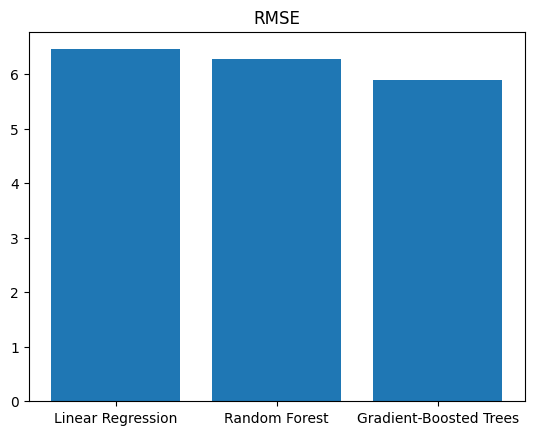

In [34]:
plt.bar(
    ["Linear Regression", "Random Forest", "Gradient-Boosted Trees"],
    [linear_regression_rmse, random_forest_rmse, gradient_boosted_trees_rmse],
)
plt.title("RMSE")
plt.show()